# Validación del backtester

El objetivo de este notebook es validar que las funciones creadas en `src/backtester.py` y `src/metrics.py` reproducen correctamente una estrategia buy and hold sobre SPY.

La estrategia buy and hold es una buena prueba inicial porque ya fue calculada manualmente en el Sprint 1.

Si el backtester funciona correctamente, sus resultados deberían ser muy parecidos a los resultados manuales.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Librerías básicas cargadas correctamente")

Librerías básicas cargadas correctamente


In [51]:
cwd = Path.cwd()

if (cwd / "requirements.txt").exists():
    project_root = cwd
else:
    project_root = cwd.parent

project_root

WindowsPath('c:/Users/usuario/Documents/GitHub/QuantLab')

In [52]:
import sys

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

src_path

WindowsPath('c:/Users/usuario/Documents/GitHub/QuantLab/src')

In [53]:
from backtester import (
    calculate_strategy_returns,
    calculate_equity_curve,
    run_backtest,
    compare_equity_curves,
)

from metrics import (
    total_return,
    annualized_return,
    annualized_volatility,
    drawdown,
    max_drawdown,
    performance_summary,
)

print("Funciones propias importadas correctamente")

Funciones propias importadas correctamente


In [54]:
processed_file = project_root / "data" / "processed" / "SPY_daily.csv"
raw_file = project_root / "data" / "raw" / "SPY_daily.csv"
raw_file_alt = project_root / "data" / "raw" / "SPY_daily_raw.csv"

if processed_file.exists():
    data_file = processed_file
elif raw_file.exists():
    data_file = raw_file
elif raw_file_alt.exists():
    data_file = raw_file_alt
else:
    raise FileNotFoundError("No encuentro el CSV de SPY.")

print("Archivo usado:", data_file)

Archivo usado: c:\Users\usuario\Documents\GitHub\QuantLab\data\processed\SPY_daily.csv


In [55]:
spy = pd.read_csv(data_file, index_col=0, parse_dates=True)

spy.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1993-01-29,24.113268,43.93750,43.96875,43.75000,43.96875,1003200
1993-02-01,24.284761,44.25000,44.25000,43.96875,43.96875,480500
1993-02-02,24.336224,44.34375,44.37500,44.12500,44.21875,201300
1993-02-03,24.593477,44.81250,44.84375,44.37500,44.40625,529400
1993-02-04,24.696363,45.00000,45.09375,44.46875,44.96875,531500


In [56]:
spy.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [57]:
price = spy["Adj Close"].copy()

returns = price.pct_change().dropna()

returns.head()

Date
1993-02-01    0.007112
1993-02-02    0.002119
1993-02-03    0.010571
1993-02-04    0.004183
1993-02-05   -0.000694
Name: Adj Close, dtype: float64

## Datos de entrada

El backtester no trabaja directamente con precios, sino con rendimientos.

A partir del precio ajustado (`Adj Close`) calculo los rendimientos diarios de SPY usando `pct_change()`.

Estos rendimientos representan la rentabilidad diaria del activo, antes de aplicar ninguna estrategia.

 # Parte A: cálculo manual de buy and hold

In [58]:
manual_equity = (1 + returns).cumprod()

manual_equity.head()

Date
1993-02-01    1.007112
1993-02-02    1.009246
1993-02-03    1.019915
1993-02-04    1.024182
1993-02-05    1.023471
Name: Adj Close, dtype: float64

In [59]:
manual_summary = pd.Series({
    "Rentabilidad total": total_return(manual_equity),
    "Rentabilidad anualizada": annualized_return(manual_equity),
    "Volatilidad anualizada": annualized_volatility(returns),
    "Máximo drawdown": max_drawdown(manual_equity),
})

manual_summary * 100

Rentabilidad total         2966.861626
Rentabilidad anualizada      10.788541
Volatilidad anualizada       18.573180
Máximo drawdown             -55.189449
dtype: float64

# Parte B: Buy and hold usando el backtester

In [60]:
buy_and_hold_position = pd.Series(1, index=returns.index)

buy_and_hold_position.head()

Date
1993-02-01    1
1993-02-02    1
1993-02-03    1
1993-02-04    1
1993-02-05    1
dtype: int64

In [61]:
backtest_returns, backtest_equity = run_backtest(
    returns=returns,
    position=buy_and_hold_position
)

backtest_equity.head()

Date
1993-02-02    1.002119
1993-02-03    1.012712
1993-02-04    1.016949
1993-02-05    1.016244
1993-02-08    1.016244
dtype: float64

In [62]:
backtest_summary = performance_summary(
    equity_curve=backtest_equity,
    returns=backtest_returns
)

backtest_summary * 100

Rentabilidad total         2960.376341
Rentabilidad anualizada      10.782451
Volatilidad anualizada       18.573929
Máximo drawdown             -55.189449
dtype: float64

Comparación manual vs backtester

In [63]:
summary_comparison = pd.DataFrame({
    "Manual": manual_summary,
    "Backtester": backtest_summary,
})

summary_comparison * 100

,Manual,Backtester
Rentabilidad total,2966.861626,2960.376341
Rentabilidad anualizada,10.788541,10.782451
Volatilidad anualizada,18.573180,18.573929
Máximo drawdown,-55.189449,-55.189449


In [64]:
summary_difference = summary_comparison["Backtester"] - summary_comparison["Manual"]

summary_difference * 100

Rentabilidad total        -6.485286e+00
Rentabilidad anualizada   -6.089291e-03
Volatilidad anualizada     7.489891e-04
Máximo drawdown           -8.881784e-14
dtype: float64

## Comparación de métricas

Las métricas manuales y las métricas del backtester deberían ser muy parecidas.

Puede existir una pequeña diferencia porque el backtester aplica la posición con `shift(1)`, lo que hace que la estrategia empiece efectivamente un día después.

Esta diferencia es aceptable y refleja una decisión conservadora para evitar look-ahead bias.

In [65]:
equity_comparison = compare_equity_curves({
    "Manual": manual_equity,
    "Backtester": backtest_equity,
})

equity_comparison.head()

,Manual,Backtester
Date,,
1993-02-02,1.009246,1.002119
1993-02-03,1.019915,1.012712
1993-02-04,1.024182,1.016949
1993-02-05,1.023471,1.016244
1993-02-08,1.023471,1.016244


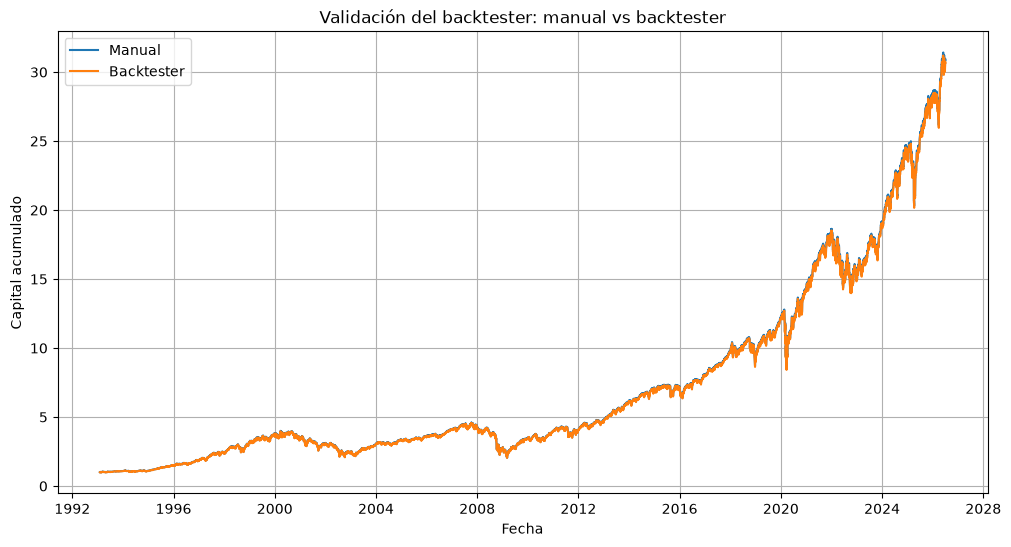

In [66]:
plt.figure(figsize=(12, 6))

for column in equity_comparison.columns:
    plt.plot(equity_comparison.index, equity_comparison[column], label=column)

plt.title("Validación del backtester: manual vs backtester")
plt.xlabel("Fecha")
plt.ylabel("Capital acumulado")
plt.legend()
plt.grid(True)
plt.show()

# Parte D: drawdawn comparativo

In [67]:
manual_drawdown = drawdown(manual_equity)
backtest_drawdown = drawdown(backtest_equity)

drawdown_comparison = compare_equity_curves({
    "Manual": manual_drawdown,
    "Backtester": backtest_drawdown,
})

drawdown_comparison.tail()

,Manual,Backtester
Date,,
2026-06-26,-0.037787,-0.037787
2026-06-29,-0.021935,-0.021935
2026-06-30,-0.014319,-0.014319
2026-07-01,-0.015652,-0.015652
2026-07-02,-0.016945,-0.016945


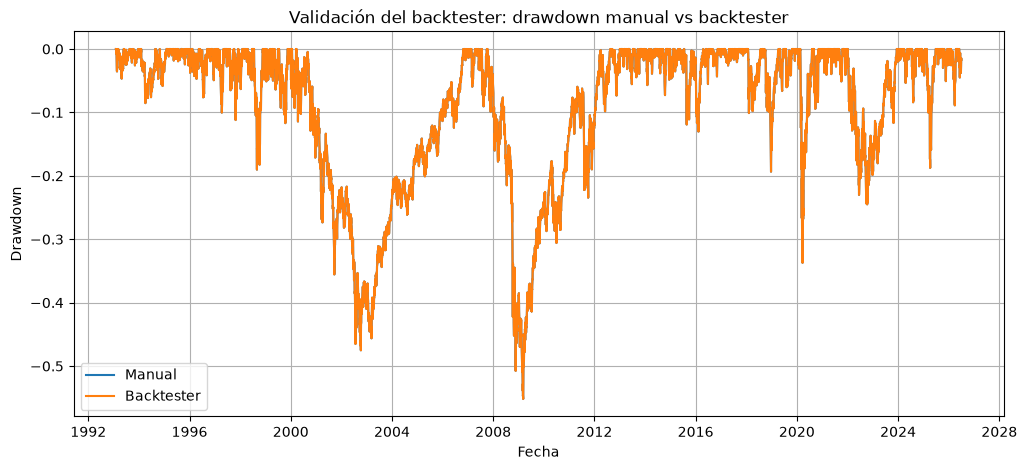

In [68]:
plt.figure(figsize=(12, 5))

for column in drawdown_comparison.columns:
    plt.plot(drawdown_comparison.index, drawdown_comparison[column], label=column)

plt.title("Validación del backtester: drawdown manual vs backtester")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

## Conclusiones

El backtester reproduce correctamente la estrategia buy and hold sobre SPY.

Las curvas de capital calculadas manualmente y mediante `run_backtest` son prácticamente iguales.

Las métricas principales también coinciden de forma muy aproximada:

- rentabilidad total;
- rentabilidad anualizada;
- volatilidad anualizada;
- máximo drawdown.

Las pequeñas diferencias se explican por el uso de `position.shift(1)`, que retrasa la aplicación de la posición un día para evitar look-ahead bias.

Con esta validación, el backtester queda preparado para evaluar estrategias donde la posición cambie en el tiempo.

# Tarea extra

In [69]:
def validate_backtest(
    manual_equity: pd.Series,
    manual_returns: pd.Series,
    backtest_equity: pd.Series,
    backtest_returns: pd.Series,
) -> pd.DataFrame:
    """
    Create a comparative board of metrics.

    Parameters
    ----------
    manual_equity : pd.Series
        Equity curve of the manual buy and hold strategy.
    manual_returns : pd.Series
        Periodic returns of the manual strategy.
    backtest_equity : pd.Series
        Equity curve of the backtester buy and hold strategy.
    backtest_returns : pd.Series
        Periodic returns of the backtester strategy.

    Returns
    -------
    pd.Series
        Summary containing two columns, one for each strategy, and four rows comparing the metrics of each strategy (total_return, annualized_return, annualized_volatility and max_drawdown)
    """
    return pd.DataFrame({
        "Manual": performance_summary(manual_equity, manual_returns),
        "Backtester": performance_summary(backtest_equity, backtest_returns),
    })

In [70]:
validation_table = validate_backtest(
    manual_equity=manual_equity,
    manual_returns=returns,
    backtest_equity=backtest_equity,
    backtest_returns=backtest_returns,
)

validation_table * 100

,Manual,Backtester
Rentabilidad total,2966.861626,2960.376341
Rentabilidad anualizada,10.788541,10.782451
Volatilidad anualizada,18.573180,18.573929
Máximo drawdown,-55.189449,-55.189449


La validación muestra que el backtester reproduce correctamente el cálculo manual de buy and hold.

Las diferencias son muy pequeñas y se explican por el uso de `position.shift(1)`, que retrasa la aplicación de la posición un día para evitar look-ahead bias.

Por tanto, el backtester queda validado para esta estrategia simple y puede usarse como base para evaluar estrategias con posiciones variables.